# NIfTI Preprocessing Pipeline — Step-by-Step Demonstration

Walks through every stage of the preprocessing pipeline on a real raw NIfTI volume:

1. **Load** NIfTI → 3D NumPy array
2. **Extract** axial slices
3. **Resize** to 224 × 224
4. **Normalize** pixel intensities to [0, 1]

**Prerequisite:** raw NIfTI data must be present under `data/raw/UT-EndoMRI/`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import yaml

# ── repo root (same robust pattern as 01_data_exploration) ──────────────
def _find_repo_root() -> Path:
    current = Path.cwd().resolve()
    for _ in range(10):
        if (current / "configs" / "config.yaml").exists():
            return current
        current = current.parent
    raise SystemExit(
        "Could not locate configs/config.yaml. Run the notebook from "
        "anywhere inside the repository."
    )

REPO_ROOT = _find_repo_root()
sys.path.insert(0, str(REPO_ROOT))

with open(REPO_ROOT / "configs" / "config.yaml", "r") as fh:
    config = yaml.safe_load(fh)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

print("Config loaded.")
print("  sequences     :", config["preprocessing"]["sequences"])
print("  image size    :", config["preprocessing"]["image_size"])

Config loaded.
  sequences     : ['T1', 'T1FS', 'T2', 'T2FS']
  image size    : [224, 224]


In [2]:
from src.preprocessing.nifti import extract_axial_slices, load_nifti
from src.preprocessing.transforms import preprocess_slice, resize_slice
from src.preprocessing.normalization import min_max_normalize
from src.data.dataset import discover_patients

RAW_DIR = REPO_ROOT / config["data"]["raw_dir"]
sequences_cfg = config["preprocessing"]["sequences"]
target_size = tuple(config["preprocessing"]["image_size"])

patients = discover_patients(RAW_DIR, sequences_cfg)

if not patients:
    raise SystemExit(
        "No raw NIfTI data found under data/raw/. "
        "Place the UT-EndoMRI dataset in data/raw/UT-EndoMRI/."
    )

print(f"Found {len(patients)} patients with raw NIfTI data.")

Found 121 patients with raw NIfTI data.


In [3]:
pid = "D2-054"

if pid not in patients:
    pid = next(iter(patients))

seq_files = patients[pid]
print(f"Patient: {pid}")
print(f"Available sequences: {[f.name for f in seq_files]}")

t2_file = next(
    (f for f in seq_files if "_T2." in f.name and "T1FS" not in f.name),
    seq_files[0],
)
print(f"\nSelected for demonstration: {t2_file.name}")

Patient: D2-054
Available sequences: ['D2-054_T1.nii.gz', 'D2-054_T1FS.nii.gz', 'D2-054_T2.nii.gz', 'D2-054_T2FS.nii.gz']

Selected for demonstration: D2-054_T2.nii.gz


## Step 1 — Load NIfTI

`load_nifti` reads a `.nii.gz` file via NiBabel and returns a raw 3D NumPy array.
The volume has arbitrary floating-point intensities (no guaranteed range).

In [4]:
volume = load_nifti(t2_file)

print(f"Shape  : {volume.shape}  (X × Y × axial slices)")
print(f"Dtype  : {volume.dtype}")
print(f"Min    : {volume.min():.2f}")
print(f"Max    : {volume.max():.2f}")
print(f"Mean   : {volume.mean():.2f}")

Shape  : (384, 384, 34)  (X × Y × axial slices)
Dtype  : float64
Min    : 0.00
Max    : 2741.42
Mean   : 570.67


## Step 2 — Extract Axial Slices

Each slice along the third axis is a single 2D grayscale image.

Extracted 34 axial slices, each with shape (384, 384)


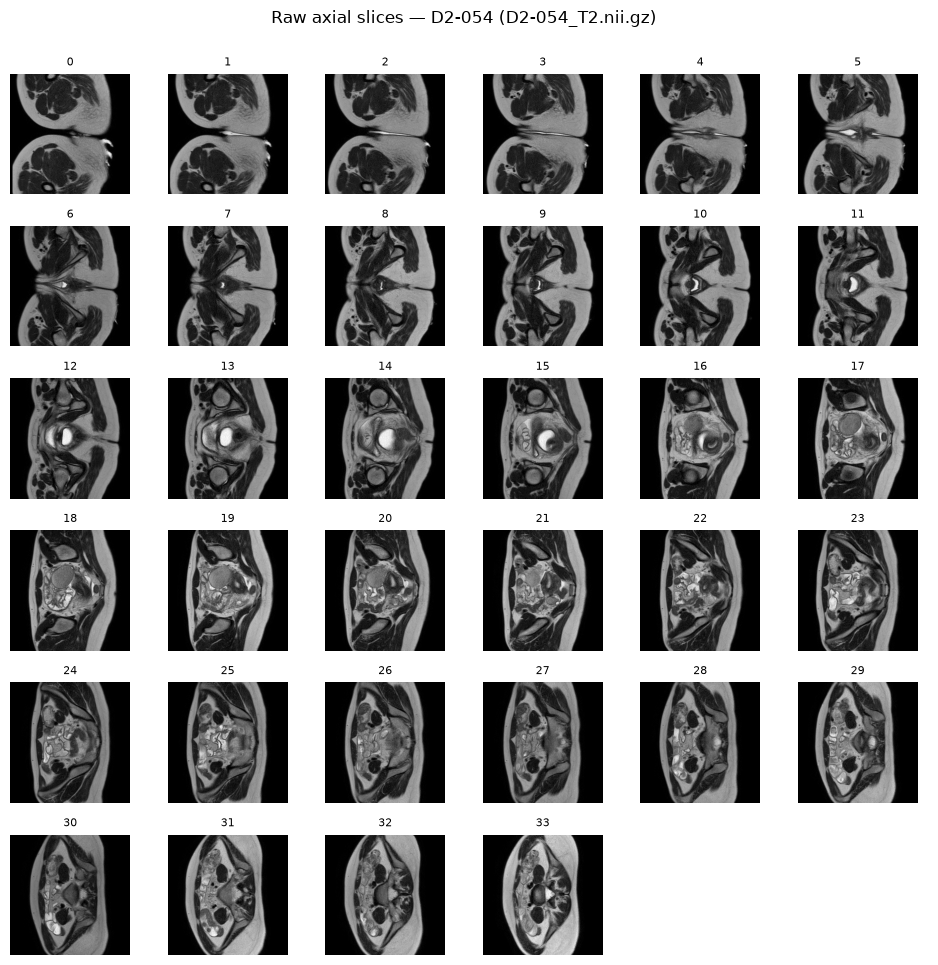

In [5]:
axial_slices = extract_axial_slices(volume)
print(f"Extracted {len(axial_slices)} axial slices, each with shape {axial_slices[0].shape}")

n = len(axial_slices)
cols = 6
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.6))
for i, ax in enumerate(axes.flat):
    if i < n:
        ax.imshow(axial_slices[i], cmap="gray")
        ax.set_title(str(i), fontsize=8)
    ax.axis("off")

plt.suptitle(f"Raw axial slices — {pid} ({t2_file.name})", y=1.0)
plt.tight_layout()
plt.show()

## Step 3 — Resize to 224 × 224

All slices are resized to match the input shape expected by ResNet50, EfficientNetV2,
and DenseNet121. Cubic interpolation preserves fine detail.

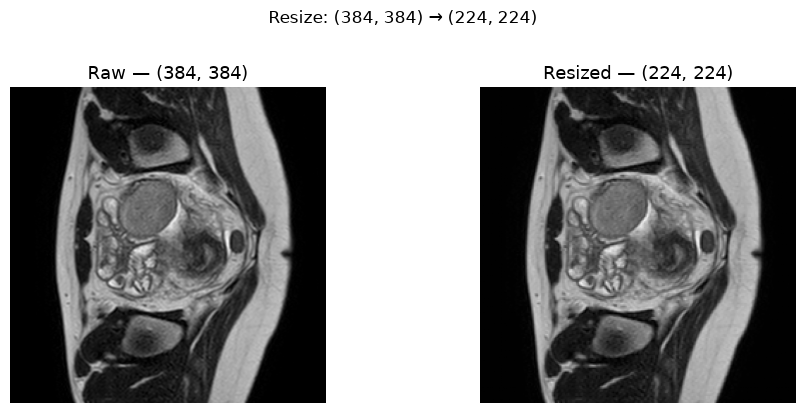

In [6]:
raw_slice = axial_slices[len(axial_slices) // 2]
resized_slice = resize_slice(raw_slice, target_size)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(raw_slice, cmap="gray")
axes[0].set_title(f"Raw — {raw_slice.shape}")
axes[0].axis("off")

axes[1].imshow(resized_slice, cmap="gray")
axes[1].set_title(f"Resized — {resized_slice.shape}")
axes[1].axis("off")

plt.suptitle(f"Resize: {raw_slice.shape} → {target_size}", y=1.02)
plt.tight_layout()
plt.show()

## Step 4 — Min-Max Normalization

Pixel intensities are scaled to the `[0, 1]` range so that all slices share a
consistent intensity scale regardless of the original MRI scanner settings.

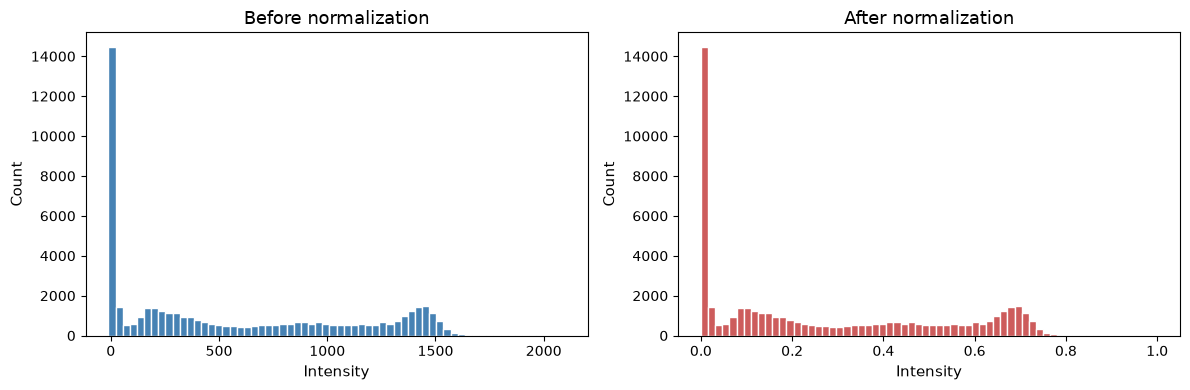

Before — min: -11.2966,  max: 2096.8320
After  — min: 0.0000,  max: 1.0000


In [7]:
normalized_slice = min_max_normalize(resized_slice)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(resized_slice.ravel(), bins=64, color="steelblue", edgecolor="white")
axes[0].set_title("Before normalization")
axes[0].set_xlabel("Intensity"); axes[0].set_ylabel("Count")

axes[1].hist(normalized_slice.ravel(), bins=64, color="indianred", edgecolor="white")
axes[1].set_title("After normalization")
axes[1].set_xlabel("Intensity"); axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Before — min: {resized_slice.min():.4f},  max: {resized_slice.max():.4f}")
print(f"After  — min: {normalized_slice.min():.4f},  max: {normalized_slice.max():.4f}")

## Step 5 — Combined `preprocess_slice`

The full pipeline in one function call: resize + normalize.
This is what `src/preprocess.py` applies to every slice before saving it as `.npy`.

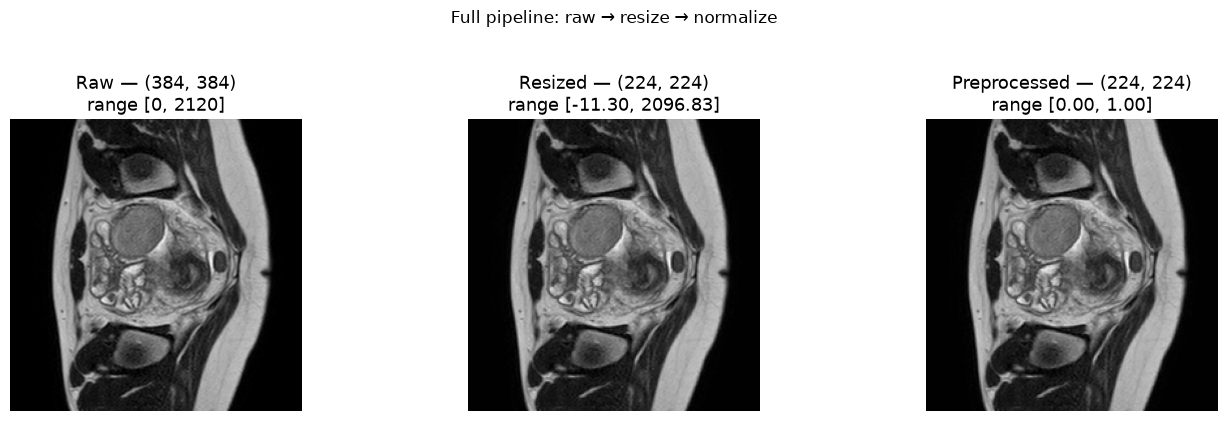

Shape  : (224, 224)
Dtype  : float32
Min    : 0.0000
Max    : 1.0000


In [8]:
final_slice = preprocess_slice(raw_slice, target_size)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(raw_slice, cmap="gray")
axes[0].set_title(f"Raw — {raw_slice.shape}\nrange [{raw_slice.min():.0f}, {raw_slice.max():.0f}]")
axes[0].axis("off")

axes[1].imshow(resized_slice, cmap="gray")
axes[1].set_title(f"Resized — {resized_slice.shape}\nrange [{resized_slice.min():.2f}, {resized_slice.max():.2f}]")
axes[1].axis("off")

axes[2].imshow(final_slice, cmap="gray")
axes[2].set_title(f"Preprocessed — {final_slice.shape}\nrange [{final_slice.min():.2f}, {final_slice.max():.2f}]")
axes[2].axis("off")

plt.suptitle("Full pipeline: raw → resize → normalize", y=1.04)
plt.tight_layout()
plt.show()

print(f"Shape  : {final_slice.shape}")
print(f"Dtype  : {final_slice.dtype}")
print(f"Min    : {final_slice.min():.4f}")
print(f"Max    : {final_slice.max():.4f}")

## What gets produced

After `python src/preprocess.py` runs, the pipeline above is applied to every slice
from every patient:
```
data/processed/
├── manifest.csv          ← filename, patient_id, sequence, split, label
├── train/
│   ├── D1-000/
│   │   ├── T1FS_slice_0000.npy    ← one 224×224 float32 array per slice
│   │   ├── T1FS_slice_0001.npy
│   │   └── ...
│   └── ...
└── validation/
    └── ...
```
Each `.npy` file is the output of `preprocess_slice` — a `(224, 224)` `float32` array
with values in `[0, 1]`. The manifest CSV maps every file back to its patient,
MRI sequence, split, and binary label.